In [1]:
# 2025.11.30 RandomForest Find HO

In [2]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
import os

import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import roc_auc_score
from sklearn.metrics         import precision_recall_curve, classification_report
from sklearn.datasets         import make_classification

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.svm            import SVC
from sklearn.metrics        import classification_report
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier

# hyperopt 용
from hyperopt               import hp

# 사용자 Functions import
import importlib
from utils import user_utils
importlib.reload(user_utils)

import HyperParams          as HP 
import utils.data_sampling  as ds 

from utils import user_utils    as uu
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu
from utils import modeling      as mo

from utils.hyperopt_search import hyperopt_search, train_and_evaluate

In [4]:
# 결과받을 딕셔너리
results = {}
team_rs = 23 # 우리팀 random_state

In [5]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [6]:
# 2. Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')

In [7]:
# 3. 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [8]:
# 4.1 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

# 5.1 학습/검증 데이터 분리
# X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [9]:
# 4.2 Over Sampling 하는 경우
X_over, y_over = ds.oversampling_smote(X_train, y_train)

# 5.2 Over Sampling한 경우 학습/검증 데이터 분리
# X_tr_over, X_val_over, y_tr_over, y_val_over = pp.data_split(X_over, y_over, size=0.4)

✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)


In [9]:
# 사용자 Functions import
import importlib
from utils import hyperopt_search
importlib.reload(hyperopt_search)


<module 'utils.hyperopt_search' from 'c:\\00.Study\\big20\\big20-ML-project2-team3\\CreditCardFraud\\utils\\hyperopt_search.py'>

In [10]:
# Search Space 정의
rf_search_space = {
    'n_estimators': hp.quniform('n_estimators', 100, 600, 50),
    'max_depth': hp.choice('max_depth', [None, 10, 20, 30, 40]),
    'min_samples_split': hp.quniform('min_samples_split', 2, 20, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 10, 1),
    'max_features': hp.choice('max_features', ['sqrt', 'log2', None]),
    'class_weight': hp.choice('class_weight', ['balanced', None, 'balanced_subsample']),
    'bootstrap': hp.choice('bootstrap', [True, False]),  # 추가 권장
    'criterion': hp.choice('criterion', ['gini', 'entropy']),  # 추가 권장
}

# RandomForestClassifier
rf_search_result = hyperopt_search(
    model_class=RandomForestClassifier,
    search_space=rf_search_space,
    X_train=X_train,
    y_train=y_train,
    max_evals=100,
    save_trials=True,
    verbose=True
)

  RandomForestClassifier 하이퍼파라미터 탐색 시작
교차 검증 오류:                                              
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\user\anaconda3\envs\ml_dev\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\user\anaconda3\envs\ml_dev\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Users\user\anaconda3\envs\ml_dev\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "c:\Users\user\anaconda3\envs\ml_dev\Lib\site-packages\sklearn\utils\_param_validation.py", line 9

In [11]:
best_params = rf_search_result['best_params']
best_params

{'bootstrap': True,
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 3,
 'max_features': None,
 'min_samples_leaf': 9,
 'min_samples_split': 3,
 'n_estimators': 200,
 'random_state': 23,
 'n_jobs': -1}

In [12]:
# 2단계: 최종 학습 및 평가
final_result = train_and_evaluate(
    model_class=RandomForestClassifier,
    params=best_params,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    save_model=True,
    verbose=True
)

print("\n" + "=" * 70)
print("완료!")
print("=" * 70)
print(f"최종 결과: {final_result['result_dict']}")
results['rf_ho_best'] = final_result['result_dict']

  RandomForestClassifier 최종 학습 및 평가
사용 파라미터: {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 9, 'min_samples_split': 3, 'n_estimators': 200, 'random_state': 23, 'n_jobs': -1}
✓ 학습 완료 (84.79초)

평가 결과:
  - accuracy: 0.9818
  - precision: 0.0766
  - recall: 0.8673
  - f1: 0.1408
  - roc_auc: 0.9610

혼동 행렬:
[[55840  1024]
 [   13    85]]

✓ 모델 저장: ../models/RandomForestClassifier_20251130_153804.pkl (0.29 MB)
✓ 결과 저장: ../results/RandomForestClassifier_result_20251130_153804.json

완료!
최종 결과: {'AUC': 0.961, '정확도': 0.9818, '정밀도': 0.0766, '재현율': 0.8673, 'F1': 0.1408}


In [13]:
# over sampling 한 경우
final_result_over = train_and_evaluate(
    model_class = RandomForestClassifier,
    params      = best_params,
    X_train     = X_over,
    y_train     = y_over,
    X_test      = X_test,
    y_test      = y_test,
    save_model  = True,
    verbose     = True
)

print("\n" + "=" * 70)
print("완료!")
print("=" * 70)
print(f"최종 결과: {final_result['result_dict']}")
results['rf_ho_best_smote'] = final_result['result_dict']

  RandomForestClassifier 최종 학습 및 평가
사용 파라미터: {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 9, 'min_samples_split': 3, 'n_estimators': 200, 'random_state': 23, 'n_jobs': -1}
✓ 학습 완료 (147.50초)

평가 결과:
  - accuracy: 0.9946
  - precision: 0.2196
  - recall: 0.8469
  - f1: 0.3487
  - roc_auc: 0.9526

혼동 행렬:
[[56569   295]
 [   15    83]]

✓ 모델 저장: ../models/RandomForestClassifier_20251130_154419.pkl (0.29 MB)
✓ 결과 저장: ../results/RandomForestClassifier_result_20251130_154419.json

완료!
최종 결과: {'AUC': 0.961, '정확도': 0.9818, '정밀도': 0.0766, '재현율': 0.8673, 'F1': 0.1408}


In [15]:
# StandardScale한 경우

X_train_sscaled, X_test_sscaled, scaler = pp.scale_data(X_train, X_test)

ss_result = train_and_evaluate(
    model_class = RandomForestClassifier,
    params      = best_params,
    X_train     = X_train_sscaled,
    y_train     = y_train,
    X_test      = X_test_sscaled,
    y_test      = y_test,
    save_model  = True,
    verbose     = True
)
results['rf_ho_best_sscaled'] = ss_result['result_dict'] 


  RandomForestClassifier 최종 학습 및 평가
사용 파라미터: {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 9, 'min_samples_split': 3, 'n_estimators': 200, 'random_state': 23, 'n_jobs': -1}
✓ 학습 완료 (80.46초)

평가 결과:
  - accuracy: 0.9818
  - precision: 0.0766
  - recall: 0.8673
  - f1: 0.1408
  - roc_auc: 0.9610

혼동 행렬:
[[55840  1024]
 [   13    85]]

✓ 모델 저장: ../models/RandomForestClassifier_20251130_154804.pkl (0.29 MB)
✓ 결과 저장: ../results/RandomForestClassifier_result_20251130_154804.json


In [16]:
# Data Scale2 
from sklearn.preprocessing import RobustScaler

rscaler = RobustScaler()
X_train_rscaled = rscaler.fit_transform(X_train)   # 학습 데이터로 fit + transform
X_test_rscaled = rscaler.transform(X_test)         # 테스트 데이터는 transform만

rs_result = train_and_evaluate(
    model_class = RandomForestClassifier,
    params      = best_params,
    X_train     = X_train_rscaled,
    y_train     = y_train,
    X_test      = X_test_rscaled,
    y_test      = y_test,
    save_model  = True,
    verbose     = True
)
results['rf_ho_best_rscaled'] = rs_result['result_dict']

  RandomForestClassifier 최종 학습 및 평가
사용 파라미터: {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 9, 'min_samples_split': 3, 'n_estimators': 200, 'random_state': 23, 'n_jobs': -1}
✓ 학습 완료 (80.09초)

평가 결과:
  - accuracy: 0.9818
  - precision: 0.0766
  - recall: 0.8673
  - f1: 0.1408
  - roc_auc: 0.9610

혼동 행렬:
[[55840  1024]
 [   13    85]]

✓ 모델 저장: ../models/RandomForestClassifier_20251130_155008.pkl (0.29 MB)
✓ 결과 저장: ../results/RandomForestClassifier_result_20251130_155008.json


In [ ]:
best_params['max_depth'] = 10

rs_result = train_and_evaluate(
    model_class = RandomForestClassifier,
    params      = best_params,
    X_train     = X_train,
    y_train     = y_train,
    X_test      = X_test,
    y_test      = y_test,
    save_model  = True,
    verbose     = True
)
results['rf_ho_best_md10'] = rs_result['result_dict']

  RandomForestClassifier 최종 학습 및 평가
사용 파라미터: {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 9, 'min_samples_split': 3, 'n_estimators': 200, 'random_state': 23, 'n_jobs': -1}
✓ 학습 완료 (124.63초)

평가 결과:
  - accuracy: 0.9994
  - precision: 0.8587
  - recall: 0.8061
  - f1: 0.8316
  - roc_auc: 0.9639

혼동 행렬:
[[56851    13]
 [   19    79]]

✓ 모델 저장: ../models/RandomForestClassifier_20251130_155351.pkl (2.54 MB)
✓ 결과 저장: ../results/RandomForestClassifier_result_20251130_155351.json


In [20]:
best_params['max_depth'] = 20

rs_result = train_and_evaluate(
    model_class = RandomForestClassifier,
    params      = best_params,
    X_train     = X_train,
    y_train     = y_train,
    X_test      = X_test,
    y_test      = y_test,
    save_model  = True,
    verbose     = True
)
results['rf_ho_best_md20'] = rs_result['result_dict']

  RandomForestClassifier 최종 학습 및 평가
사용 파라미터: {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 9, 'min_samples_split': 3, 'n_estimators': 200, 'random_state': 23, 'n_jobs': -1}
✓ 학습 완료 (124.57초)

평가 결과:
  - accuracy: 0.9995
  - precision: 0.8681
  - recall: 0.8061
  - f1: 0.8360
  - roc_auc: 0.9547

혼동 행렬:
[[56852    12]
 [   19    79]]

✓ 모델 저장: ../models/RandomForestClassifier_20251130_155808.pkl (3.05 MB)
✓ 결과 저장: ../results/RandomForestClassifier_result_20251130_155808.json


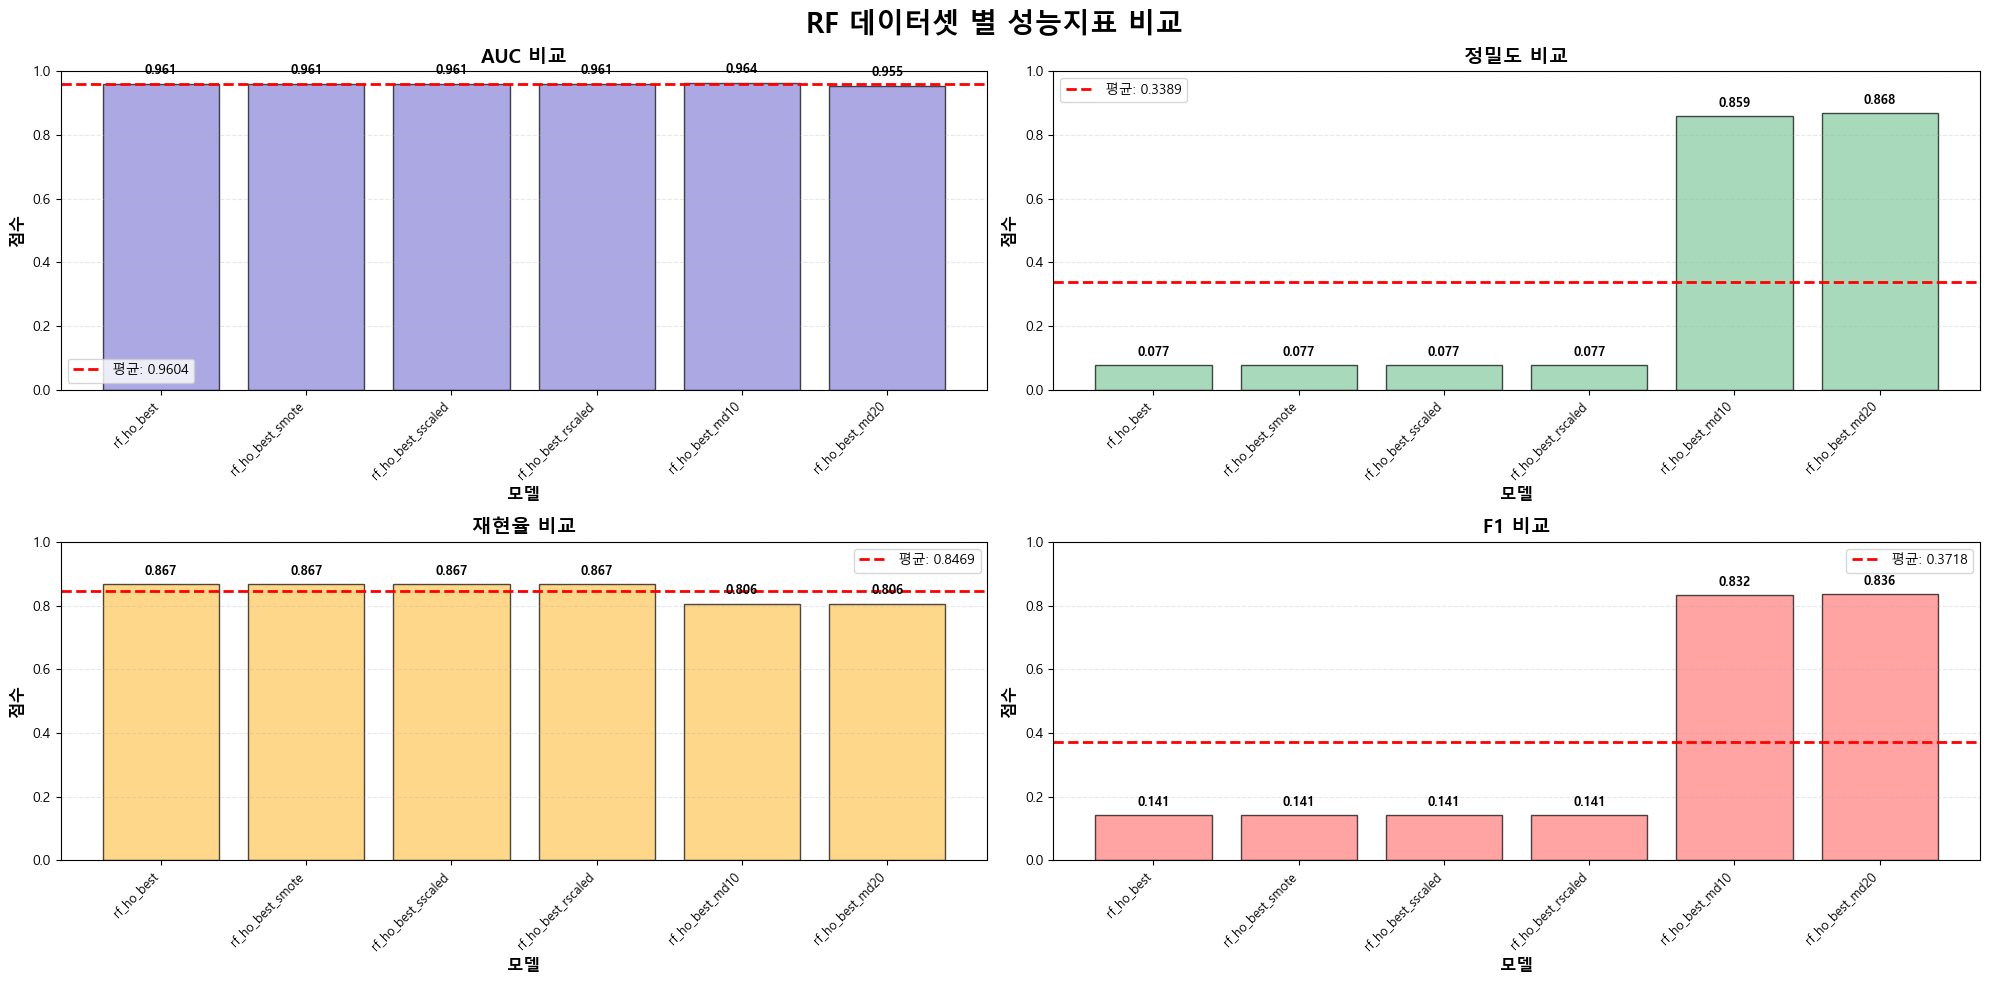


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9639 (rf_ho_best_md10)
  최저: 0.9547 (rf_ho_best_md20)
  평균: 0.9604
  표준편차: 0.0030

[정밀도]
  최고: 0.8681 (rf_ho_best_md20)
  최저: 0.0766 (rf_ho_best)
  평균: 0.3389
  표준편차: 0.4063

[재현율]
  최고: 0.8673 (rf_ho_best)
  최저: 0.8061 (rf_ho_best_md10)
  평균: 0.8469
  표준편차: 0.0316

[F1]
  최고: 0.8360 (rf_ho_best_md20)
  최저: 0.1408 (rf_ho_best)
  평균: 0.3718
  표준편차: 0.3579


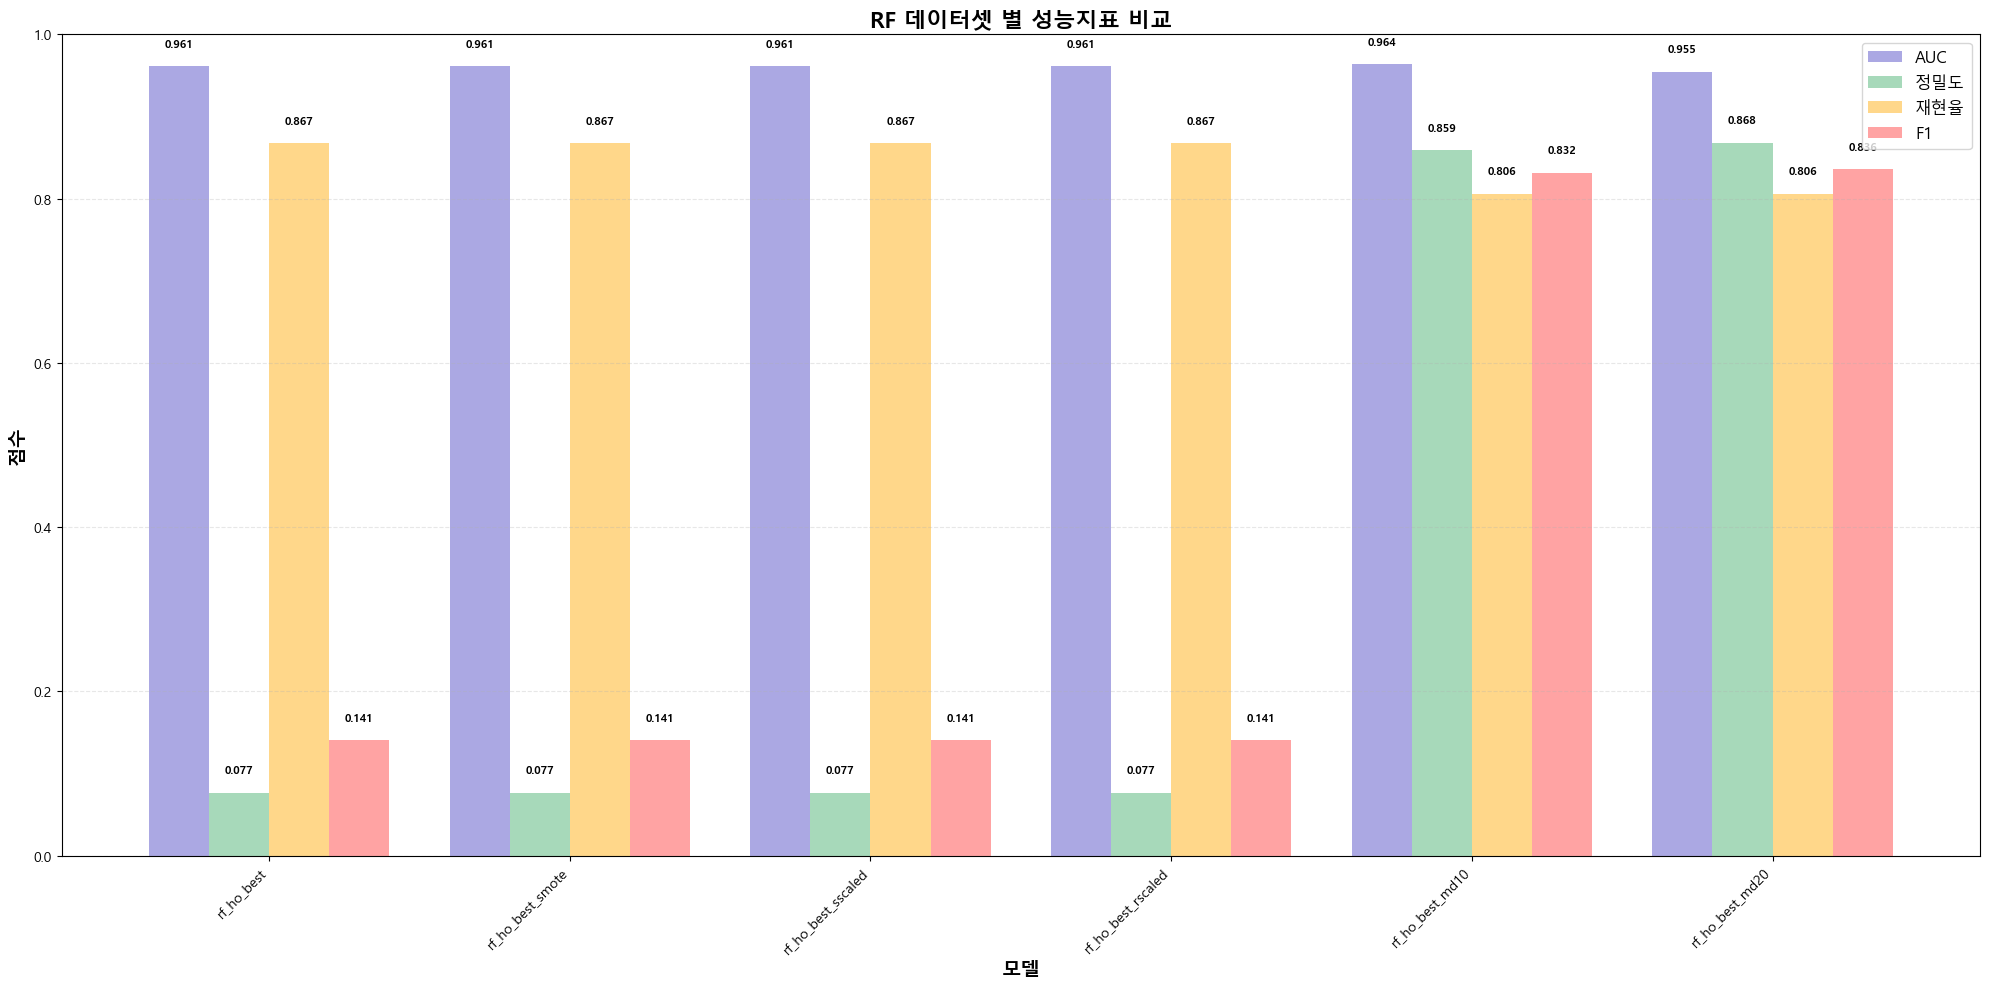


=== F1 Score 기준 상위 5개 모델 ===
                       AUC     정밀도     재현율      F1
rf_ho_best_md20     0.9547  0.8681  0.8061  0.8360
rf_ho_best_md10     0.9639  0.8587  0.8061  0.8316
rf_ho_best          0.9610  0.0766  0.8673  0.1408
rf_ho_best_smote    0.9610  0.0766  0.8673  0.1408
rf_ho_best_sscaled  0.9610  0.0766  0.8673  0.1408

=== AUC 기준 상위 5개 모델 ===
                       AUC     정밀도     재현율      F1
rf_ho_best_md10     0.9639  0.8587  0.8061  0.8316
rf_ho_best          0.9610  0.0766  0.8673  0.1408
rf_ho_best_smote    0.9610  0.0766  0.8673  0.1408
rf_ho_best_sscaled  0.9610  0.0766  0.8673  0.1408
rf_ho_best_rscaled  0.9610  0.0766  0.8673  0.1408

그래프가 저장되었습니다: ../images/RF_데이터셋_별_성능지표_비교_2025_1130.png


In [21]:
# 7 시각화
mo.model_metrics_graph(results, 'RF 데이터셋 별 성능지표 비교')